In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

takapuna = pd.read_csv("ASS2data1.csv")
takapuna.head()

,StartofInterval,EndofInterval,"PM2,5.Hourly Aggregate (µg/m³) Average (µg/m³)",PM10.Hourly Aggregate (µg/m³) Average (µg/m³),NO.Hourly Aggregate (µg/m³) Average (mg/m³),NO2.Hourly Aggregate (µg/m³) Average (µg/m³),Air Temp.Hourly Aggregate (°C) Average (°C),Rel Humidity.Hourly Aggregate (%) Average (%),Wind Dir.Hourly Aggregate (°) Average (°),Wind Speed m/s.Hourly Aggregate (m/s) Average (m/s)
0,01-01-2019 00:00,01-01-2019 01:00,10.30,14.80,NaN,NaN,19.0,75.30,230.0,1.15
1,01-01-2019 01:00,01-01-2019 02:00,7.60,14.20,NaN,NaN,19.0,76.05,231.0,1.00
2,01-01-2019 02:00,01-01-2019 03:00,4.90,18.80,0.0030,6.50,19.0,76.70,246.0,1.10
3,01-01-2019 03:00,01-01-2019 04:00,7.25,19.65,0.0025,5.10,19.0,77.35,252.5,1.20
4,01-01-2019 04:00,01-01-2019 05:00,7.55,16.65,0.0021,3.75,19.0,77.20,250.0,1.45


In [2]:
#A)Data preprocessing

print(list(takapuna));
print("Number of observations in the data set:",takapuna.shape[0]);
takapuna.drop_duplicates() 
print("Number of observations in the data set:",takapuna.shape[0]);
print(takapuna.isnull().values.any());
print(takapuna.isnull().sum())
print("Total number of null values:",sum(takapuna.isnull().sum()))


['StartofInterval', 'EndofInterval', 'PM2,5.Hourly Aggregate (µg/m³)  Average (µg/m³)', 'PM10.Hourly Aggregate (µg/m³) Average (µg/m³)', 'NO.Hourly Aggregate (µg/m³) Average (mg/m³)', 'NO2.Hourly Aggregate (µg/m³) Average (µg/m³)', 'Air Temp.Hourly Aggregate (°C) Average (°C)', 'Rel Humidity.Hourly Aggregate (%) Average (%)', 'Wind Dir.Hourly Aggregate (°) Average (°)', 'Wind Speed m/s.Hourly Aggregate (m/s) Average (m/s)']
Number of observations in the data set: 43800
Number of observations in the data set: 43800
True
StartofInterval                                            0
EndofInterval                                              0
PM2,5.Hourly Aggregate (µg/m³)  Average (µg/m³)        16126
PM10.Hourly Aggregate (µg/m³) Average (µg/m³)           1955
NO.Hourly Aggregate (µg/m³) Average (mg/m³)             4430
NO2.Hourly Aggregate (µg/m³) Average (µg/m³)            4430
Air Temp.Hourly Aggregate (°C) Average (°C)             5809
Rel Humidity.Hourly Aggregate (%) Average (%)   

In [3]:

print("Number of observation in the data:",takapuna.shape)
print(takapuna.dtypes)


Number of observation in the data: (43800, 10)
StartofInterval                                         object
EndofInterval                                           object
PM2,5.Hourly Aggregate (µg/m³)  Average (µg/m³)        float64
PM10.Hourly Aggregate (µg/m³) Average (µg/m³)          float64
NO.Hourly Aggregate (µg/m³) Average (mg/m³)            float64
NO2.Hourly Aggregate (µg/m³) Average (µg/m³)           float64
Air Temp.Hourly Aggregate (°C) Average (°C)            float64
Rel Humidity.Hourly Aggregate (%) Average (%)          float64
Wind Dir.Hourly Aggregate (°) Average (°)              float64
Wind Speed m/s.Hourly Aggregate (m/s) Average (m/s)    float64
dtype: object


In [4]:
# Convert datetime columns to datetime data type with correct format
takapuna['StartofInterval'] = pd.to_datetime(takapuna['StartofInterval'], format='%d-%m-%Y %H:%M')
takapuna['EndofInterval'] = pd.to_datetime(takapuna['EndofInterval'], format='%d-%m-%Y %H:%M')




print(takapuna.dtypes)

StartofInterval                                        datetime64[ns]
EndofInterval                                          datetime64[ns]
PM2,5.Hourly Aggregate (µg/m³)  Average (µg/m³)               float64
PM10.Hourly Aggregate (µg/m³) Average (µg/m³)                 float64
NO.Hourly Aggregate (µg/m³) Average (mg/m³)                   float64
NO2.Hourly Aggregate (µg/m³) Average (µg/m³)                  float64
Air Temp.Hourly Aggregate (°C) Average (°C)                   float64
Rel Humidity.Hourly Aggregate (%) Average (%)                 float64
Wind Dir.Hourly Aggregate (°) Average (°)                     float64
Wind Speed m/s.Hourly Aggregate (m/s) Average (m/s)           float64
dtype: object


In [5]:
means = takapuna.mean()

# Replace NaN values with the mean of the respective columns
takapuna1 = takapuna.fillna(means)
print(takapuna1.isnull().sum())

StartofInterval                                        0
EndofInterval                                          0
PM2,5.Hourly Aggregate (µg/m³)  Average (µg/m³)        0
PM10.Hourly Aggregate (µg/m³) Average (µg/m³)          0
NO.Hourly Aggregate (µg/m³) Average (mg/m³)            0
NO2.Hourly Aggregate (µg/m³) Average (µg/m³)           0
Air Temp.Hourly Aggregate (°C) Average (°C)            0
Rel Humidity.Hourly Aggregate (%) Average (%)          0
Wind Dir.Hourly Aggregate (°) Average (°)              0
Wind Speed m/s.Hourly Aggregate (m/s) Average (m/s)    0
dtype: int64


In [6]:
stats = takapuna1.describe().loc[['min', 'max', 'mean']]
print(stats)

          StartofInterval        EndofInterval  \
min   2019-01-01 00:00:00  2019-01-01 01:00:00   
max   2023-12-30 23:00:00  2023-12-31 00:00:00   
mean  2021-07-01 11:30:00  2021-07-01 12:30:00   

      PM2,5.Hourly Aggregate (µg/m³)  Average (µg/m³)  \
min                                         -6.350000   
max                                         52.300000   
mean                                         6.724297   

      PM10.Hourly Aggregate (µg/m³) Average (µg/m³)  \
min                                       -3.800000   
max                                      437.250000   
mean                                      12.408367   

      NO.Hourly Aggregate (µg/m³) Average (mg/m³)  \
min                                     -0.000900   
max                                      0.378950   
mean                                     0.012878   

      NO2.Hourly Aggregate (µg/m³) Average (µg/m³)  \
min                                      -1.150000   
max                         

In [7]:
cols_to_check_negative = [
    'PM10.Hourly Aggregate (µg/m³) Average (µg/m³)',
    'NO.Hourly Aggregate (µg/m³) Average (mg/m³)',    
    'NO2.Hourly Aggregate (µg/m³) Average (µg/m³)',
    'PM2,5.Hourly Aggregate (µg/m³)  Average (µg/m³)'
]

# Remove rows with negative values in the specified columns
for col in cols_to_check_negative:
    takapuna1 = takapuna1[takapuna1[col] >= 0]
    
stats1 = takapuna1.describe().loc[['min', 'max', 'mean']]
print(stats1)
print("Number of observations in the data:", takapuna1.shape[0])

                    StartofInterval                  EndofInterval  \
min             2019-01-01 00:00:00            2019-01-01 01:00:00   
max             2023-12-30 23:00:00            2023-12-31 00:00:00   
mean  2021-07-05 16:06:37.071701760  2021-07-05 17:06:37.071701760   

      PM2,5.Hourly Aggregate (µg/m³)  Average (µg/m³)  \
min                                          0.200000   
max                                         52.300000   
mean                                         6.738494   

      PM10.Hourly Aggregate (µg/m³) Average (µg/m³)  \
min                                        0.000000   
max                                      437.250000   
mean                                      12.442415   

      NO.Hourly Aggregate (µg/m³) Average (mg/m³)  \
min                                      0.000000   
max                                      0.378950   
mean                                     0.013048   

      NO2.Hourly Aggregate (µg/m³) Average (µg/m³)  \
mi

In [8]:
# Define a function to identify outliers
def detect_outliers(series, lower_bound=None, upper_bound=None):
    outliers = (series < lower_bound) | (series > upper_bound)
    return outliers

def filter_outliers(takapuna1, column, lower_bound, upper_bound):
    return takapuna1[(takapuna1[column] >= lower_bound) & (takapuna1[column] <= upper_bound)]

# Define expected ranges for the attributes
ranges = {
    'Air Temp.Hourly Aggregate (°C) Average (°C)': (5, 30),
    'Rel Humidity.Hourly Aggregate (%) Average (%)': (60, 100),
    'PM2,5.Hourly Aggregate (µg/m³)  Average (µg/m³)':(3,10),
    'PM10.Hourly Aggregate (µg/m³) Average (µg/m³)':(10,20),
    'NO.Hourly Aggregate (µg/m³) Average (mg/m³)':(0,2),
    'NO2.Hourly Aggregate (µg/m³) Average (µg/m³)':(0,50),
    'Wind Dir.Hourly Aggregate (°) Average (°)':(0,360),
    'Wind Speed m/s.Hourly Aggregate (m/s) Average (m/s)':(0,6)    
}


# Detect outliers
outliers_info = {}
for col, (lower, upper) in ranges.items():
    outliers_info[col] = detect_outliers(takapuna1[col], lower, upper).sum()
    
    
total_outliers = sum(outliers_info.values())    
print(outliers_info)
print(total_outliers)
print("Number of observations in the data:", takapuna1.shape[0])


for col, (lower, upper) in ranges.items():
    takapuna2 = filter_outliers(takapuna1, col, lower, upper)

print("Number of observations in the cleaned data:", takapuna2.shape[0])


{'Air Temp.Hourly Aggregate (°C) Average (°C)': 44, 'Rel Humidity.Hourly Aggregate (%) Average (%)': 7413, 'PM2,5.Hourly Aggregate (µg/m³)  Average (µg/m³)': 4698, 'PM10.Hourly Aggregate (µg/m³) Average (µg/m³)': 20818, 'NO.Hourly Aggregate (µg/m³) Average (mg/m³)': 0, 'NO2.Hourly Aggregate (µg/m³) Average (µg/m³)': 422, 'Wind Dir.Hourly Aggregate (°) Average (°)': 0, 'Wind Speed m/s.Hourly Aggregate (m/s) Average (m/s)': 567}
33962
Number of observations in the data: 43165
Number of observations in the cleaned data: 42598


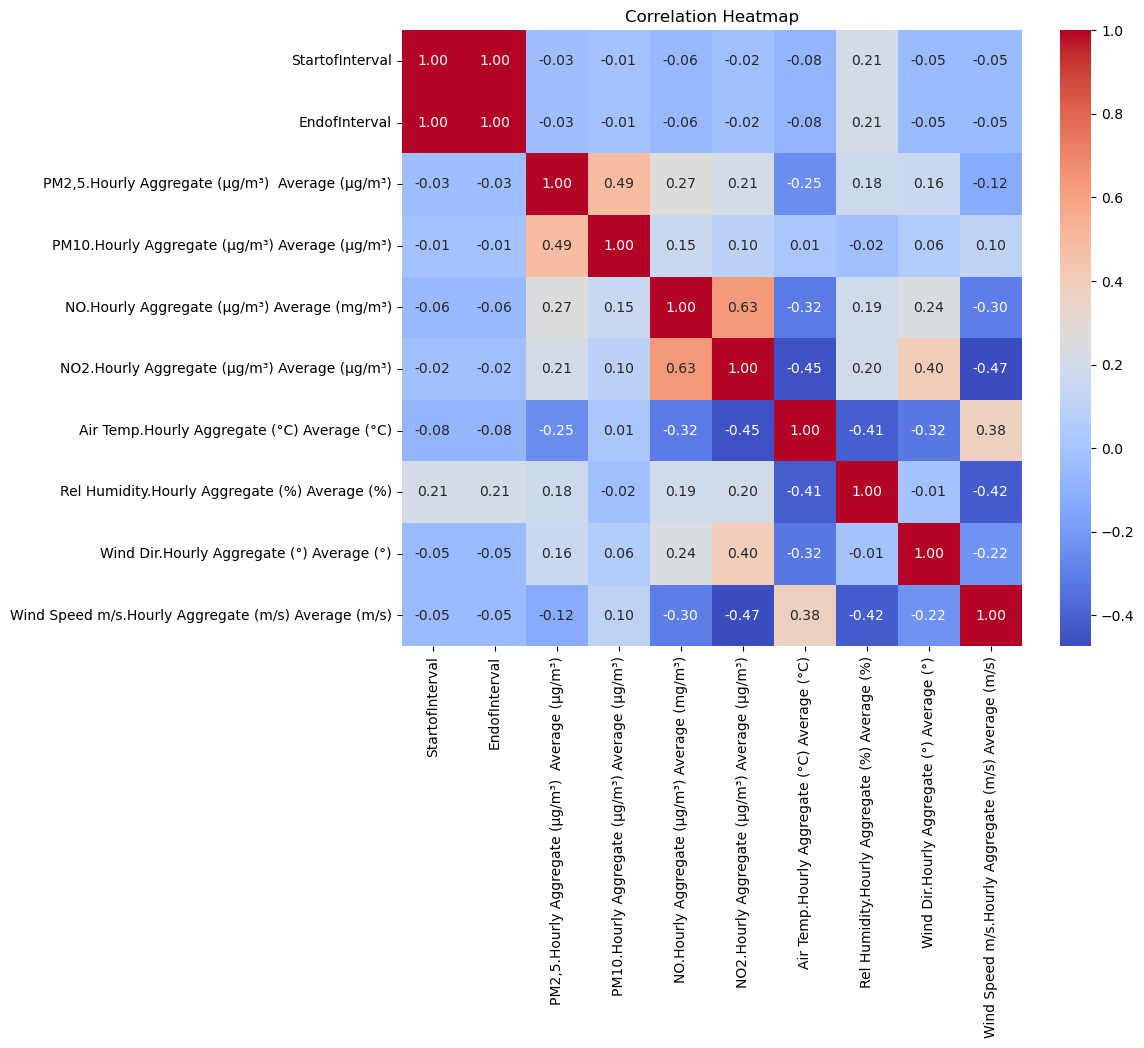

,PM10.Hourly Aggregate (µg/m³) Average (µg/m³)
StartofInterval,-0.009520
EndofInterval,-0.009520
"PM2,5.Hourly Aggregate (µg/m³) Average (µg/m³)",0.488650
PM10.Hourly Aggregate (µg/m³) Average (µg/m³),1.000000
NO.Hourly Aggregate (µg/m³) Average (mg/m³),0.154795
NO2.Hourly Aggregate (µg/m³) Average (µg/m³),0.095611
Air Temp.Hourly Aggregate (°C) Average (°C),0.013078
Rel Humidity.Hourly Aggregate (%) Average (%),-0.022257
Wind Dir.Hourly Aggregate (°) Average (°),0.056088
Wind Speed m/s.Hourly Aggregate (m/s) Average (m/s),0.103410


In [9]:
import seaborn as sns
corr_matrix = takapuna2.corr(method = 'pearson')
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()
# Extract the correlations with PM2.5 and PM10
pm_correlations = corr_matrix[[ 'PM10.Hourly Aggregate (µg/m³) Average (µg/m³)']]

# Display the correlations
pm_correlations

In [10]:
top_predictors_pm10 = pm_correlations['PM10.Hourly Aggregate (µg/m³) Average (µg/m³)'].abs().sort_values(ascending=False).index[1:7]

print(top_predictors_pm10)

Index(['PM2,5.Hourly Aggregate (µg/m³)  Average (µg/m³)',
       'NO.Hourly Aggregate (µg/m³) Average (mg/m³)',
       'Wind Speed m/s.Hourly Aggregate (m/s) Average (m/s)',
       'NO2.Hourly Aggregate (µg/m³) Average (µg/m³)',
       'Wind Dir.Hourly Aggregate (°) Average (°)',
       'Rel Humidity.Hourly Aggregate (%) Average (%)'],
      dtype='object')


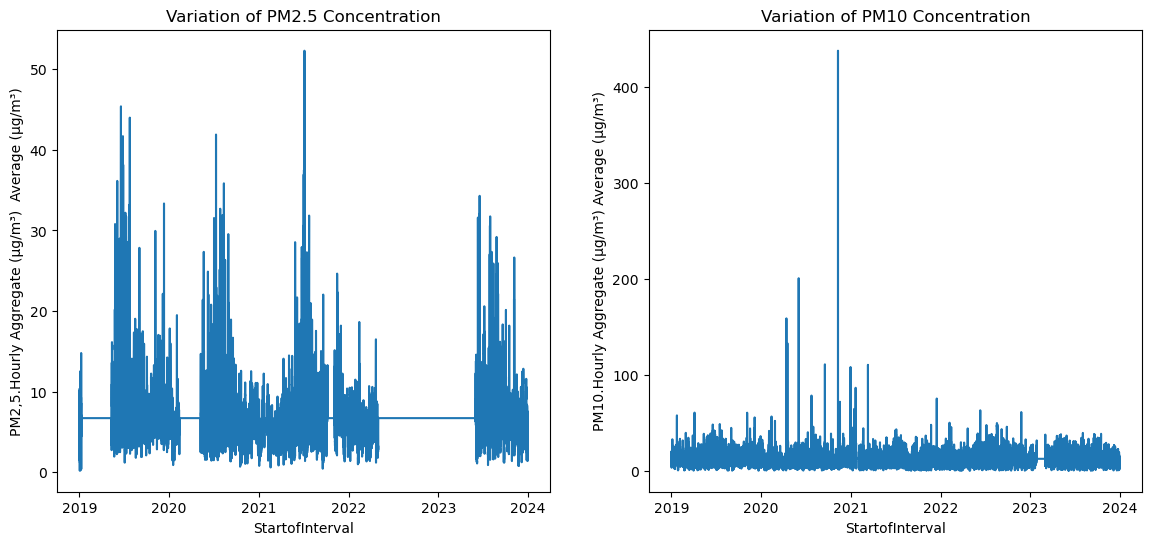

In [11]:
# Plotting the variation of PM concentrations
plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
sns.lineplot(data=takapuna2, x='StartofInterval', y='PM2,5.Hourly Aggregate (µg/m³)  Average (µg/m³)')
plt.title('Variation of PM2.5 Concentration')

plt.subplot(1, 2, 2)
sns.lineplot(data=takapuna2, x='StartofInterval', y='PM10.Hourly Aggregate (µg/m³) Average (µg/m³)')
plt.title('Variation of PM10 Concentration')

plt.show()

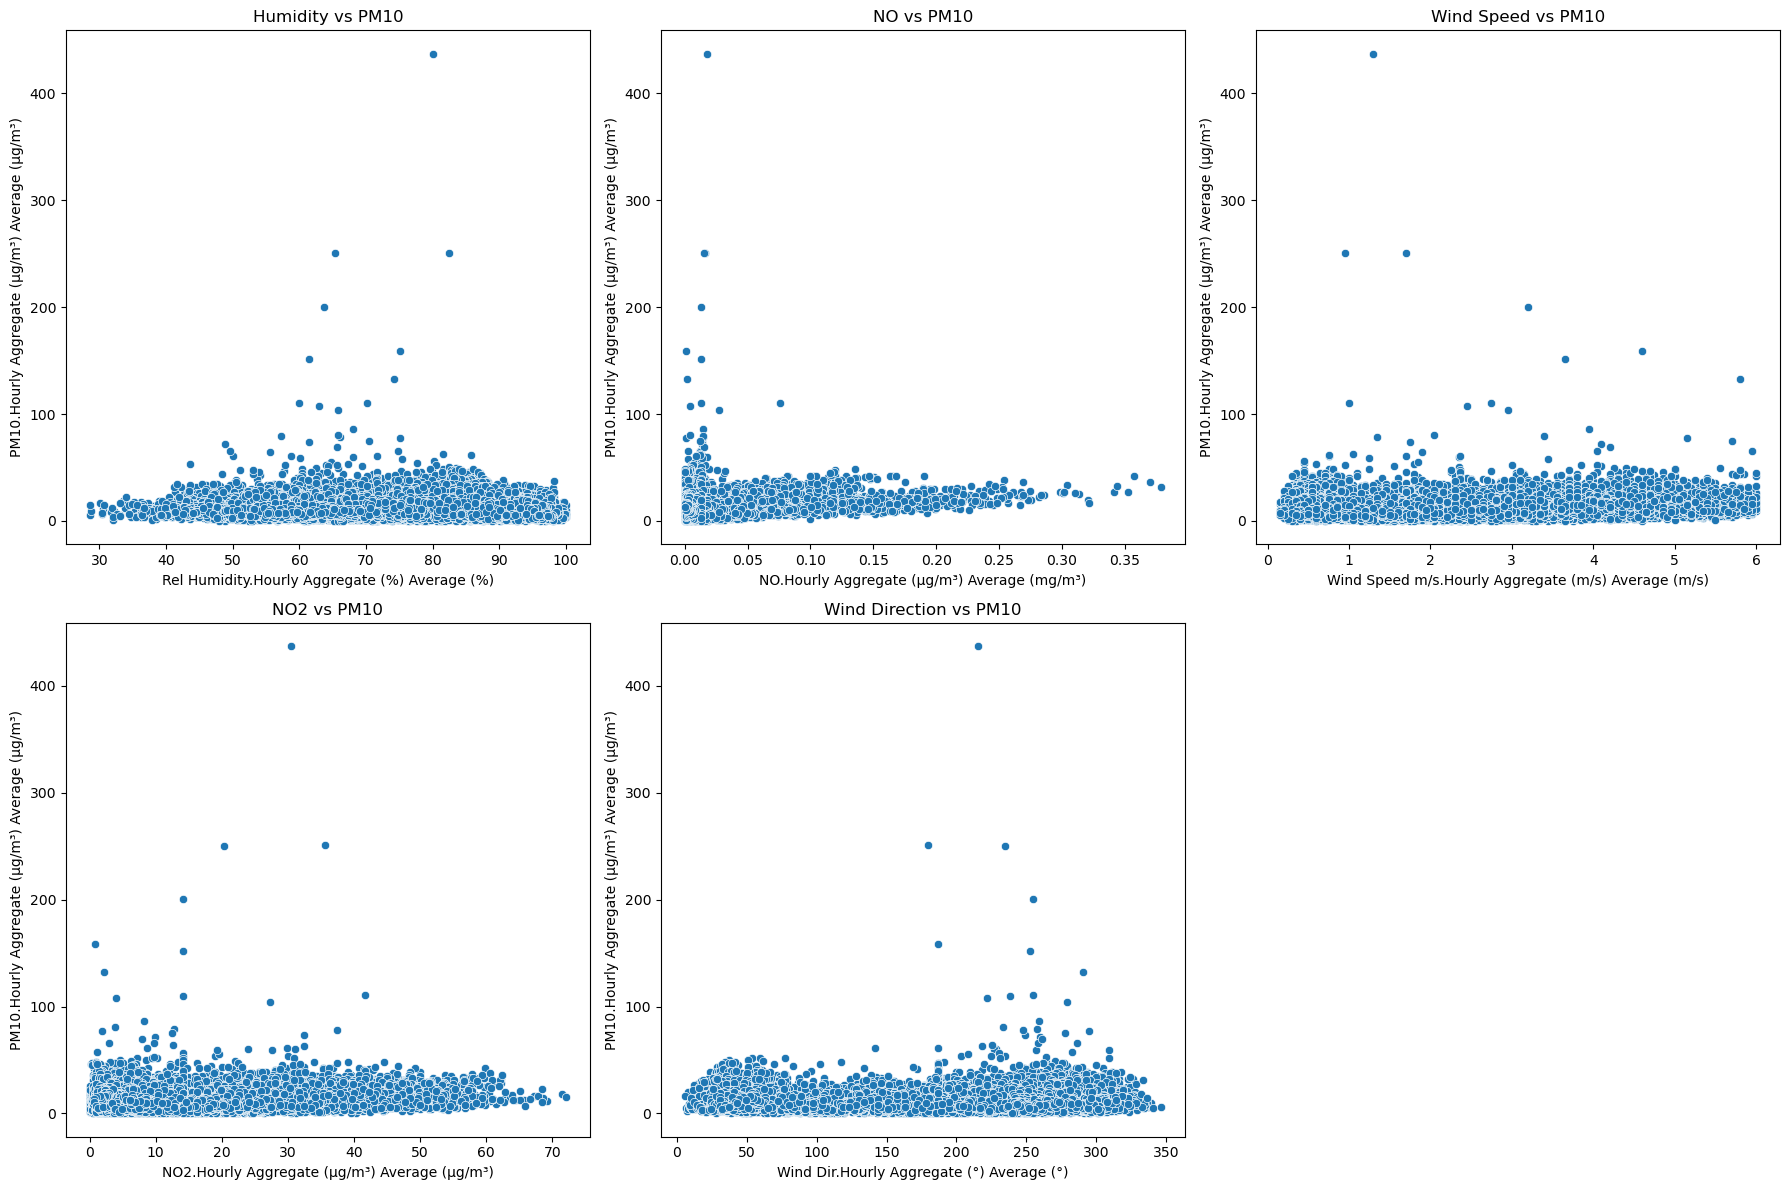

In [12]:

# Plotting the variation of each variable against PM10
plt.figure(figsize=(18, 12))

# Plot 1: PM2.5 against PM10
plt.subplot(2, 3, 1)
sns.scatterplot(data=takapuna2, x='Rel Humidity.Hourly Aggregate (%) Average (%)', y='PM10.Hourly Aggregate (µg/m³) Average (µg/m³)')
plt.title('Humidity vs PM10')

# Plot 2: NO against PM10
plt.subplot(2, 3, 2)
sns.scatterplot(data=takapuna2, x='NO.Hourly Aggregate (µg/m³) Average (mg/m³)', y='PM10.Hourly Aggregate (µg/m³) Average (µg/m³)')
plt.title('NO vs PM10')

# Plot 3: Wind Speed against PM10
plt.subplot(2, 3, 3)
sns.scatterplot(data=takapuna2, x='Wind Speed m/s.Hourly Aggregate (m/s) Average (m/s)', y='PM10.Hourly Aggregate (µg/m³) Average (µg/m³)')
plt.title('Wind Speed vs PM10')

# Plot 4: NO2 against PM10
plt.subplot(2, 3, 4)
sns.scatterplot(data=takapuna2, x='NO2.Hourly Aggregate (µg/m³) Average (µg/m³)', y='PM10.Hourly Aggregate (µg/m³) Average (µg/m³)')
plt.title('NO2 vs PM10')

# Plot 5: Wind Direction against PM10
plt.subplot(2, 3, 5)
sns.scatterplot(data=takapuna2, x='Wind Dir.Hourly Aggregate (°) Average (°)', y='PM10.Hourly Aggregate (µg/m³) Average (µg/m³)')
plt.title('Wind Direction vs PM10')

plt.tight_layout()
plt.show()

In [13]:
#Creating new dataset with just the predictors
columns = ['EndofInterval','PM10.Hourly Aggregate (µg/m³) Average (µg/m³)','NO.Hourly Aggregate (µg/m³) Average (mg/m³)',
           'Wind Speed m/s.Hourly Aggregate (m/s) Average (m/s)', 'NO2.Hourly Aggregate (µg/m³) Average (µg/m³)',
           'Wind Dir.Hourly Aggregate (°) Average (°)','Rel Humidity.Hourly Aggregate (%) Average (%)']

# Create a new DataFrame with only the specified columns
takapunalstm = takapuna2[columns].copy()
takapunalstm.head()

,EndofInterval,PM10.Hourly Aggregate (µg/m³) Average (µg/m³),NO.Hourly Aggregate (µg/m³) Average (mg/m³),Wind Speed m/s.Hourly Aggregate (m/s) Average (m/s),NO2.Hourly Aggregate (µg/m³) Average (µg/m³),Wind Dir.Hourly Aggregate (°) Average (°),Rel Humidity.Hourly Aggregate (%) Average (%)
0,2019-01-01 01:00:00,14.80,0.012878,1.15,14.134854,230.0,75.30
1,2019-01-01 02:00:00,14.20,0.012878,1.00,14.134854,231.0,76.05
2,2019-01-01 03:00:00,18.80,0.003000,1.10,6.500000,246.0,76.70
3,2019-01-01 04:00:00,19.65,0.002500,1.20,5.100000,252.5,77.35
4,2019-01-01 05:00:00,16.65,0.002100,1.45,3.750000,250.0,77.20


In [14]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import *
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.metrics import MeanAbsoluteError, RootMeanSquaredError
from sklearn.metrics import r2_score 
from sklearn.metrics import mean_squared_error 
from sklearn.metrics import mean_absolute_error 

import math

import warnings
warnings.filterwarnings('ignore')

In [15]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split





# Convert 'EndofInterval' to datetime
takapunalstm['EndofInterval'] = pd.to_datetime(takapunalstm['EndofInterval'])
# Convert datetime to timestamp (float64)
takapunalstm['EndofInterval'] = takapunalstm['EndofInterval'].astype(np.int64) / 10**9
# Reset index to the timestamp

takapunalstm.head()

,EndofInterval,PM10.Hourly Aggregate (µg/m³) Average (µg/m³),NO.Hourly Aggregate (µg/m³) Average (mg/m³),Wind Speed m/s.Hourly Aggregate (m/s) Average (m/s),NO2.Hourly Aggregate (µg/m³) Average (µg/m³),Wind Dir.Hourly Aggregate (°) Average (°),Rel Humidity.Hourly Aggregate (%) Average (%)
0,1.546304e+09,14.80,0.012878,1.15,14.134854,230.0,75.30
1,1.546308e+09,14.20,0.012878,1.00,14.134854,231.0,76.05
2,1.546312e+09,18.80,0.003000,1.10,6.500000,246.0,76.70
3,1.546315e+09,19.65,0.002500,1.20,5.100000,252.5,77.35
4,1.546319e+09,16.65,0.002100,1.45,3.750000,250.0,77.20


In [16]:


takapunalstm.drop('EndofInterval', axis=1, inplace=True)

# creating train and test sets
dataset = takapunalstm.values



n = len(dataset)
train = dataset[0:int(n * 0.7)]  # 0 ~~ 70%
valid = dataset[int(n * 0.7):]  # 70% ~~ end

scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(dataset)

print(scaled_data)

[[0.03384791 0.03398284 0.17094017 0.19604513 0.65835777 0.65430371]
 [0.0324757  0.03398284 0.14529915 0.19604513 0.66129032 0.66480056]
 [0.042996   0.00791661 0.16239316 0.09015257 0.70527859 0.67389783]
 ...
 [0.02435678 0.00580552 0.07692308 0.20110957 0.88709677 0.69489153]
 [0.02229846 0.00356248 0.11111111 0.1518724  0.50733138 0.74527642]
 [0.02904517 0.00105555 0.11965812 0.08460472 0.12903226 0.8383485 ]]


In [17]:
# Define Cost Function
def mean_squared_error(y_true, y_pred):
    return np.mean(np.square(y_true - y_pred))

# Assuming the dataset and preprocessing are done


# Scale the data
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_train = scaler.fit_transform(train)
scaled_valid = scaler.transform(valid)

# Define time steps
time_step = 100

# Prepare training data
x_train, y_train = [], []
for i in range(time_step, len(scaled_train)):
    x_train.append(scaled_train[i - time_step:i, 0])
    y_train.append(scaled_train[i, 0])
x_train, y_train = np.array(x_train), np.array(y_train)
x_train = np.reshape(x_train, (x_train.shape[0], x_train.shape[1], 1))

# Prepare validation data
x_valid, y_valid = [], []
for i in range(time_step, len(scaled_valid)):
    x_valid.append(scaled_valid[i - time_step:i, 0])
    y_valid.append(scaled_valid[i, 0])
x_valid, y_valid = np.array(x_valid), np.array(y_valid)
x_valid = np.reshape(x_valid, (x_valid.shape[0], x_valid.shape[1], 1))

# Build the LSTM model
model = Sequential()
model.add(LSTM(units=50, return_sequences=True, input_shape=(x_train.shape[1], 1)))
model.add(Dropout(0.2))
model.add(LSTM(units=50, return_sequences=True))
model.add(Dropout(0.2))
model.add(LSTM(units=50, return_sequences=True))
model.add(Dropout(0.2))
model.add(LSTM(units=50))
model.add(Dropout(0.2))
model.add(Dense(1))

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.01), loss='mean_squared_error')





In [18]:
import time
# Initialize lists to store losses and run times
train_losses = []
val_losses = []
run_times = []

runs = 30
batch_size = 4
epochs = 10

for run in range(runs):
    start_time = time.time()
    
    # Fit the model
    history = model.fit(x_train, y_train, epochs=epochs, batch_size=batch_size, validation_data=(x_valid, y_valid), verbose=1)
    
    end_time = time.time()

    # Append losses for each epoch
    train_losses.append(history.history['loss'])
    val_losses.append(history.history['val_loss'])
    run_times.append(end_time - start_time)

    # Print progress
    print(f"Run {run + 1} completed in {end_time - start_time} sec")


Epoch 1/2
  93/7430 ━━━━━━━━━━━━━━━━━━━━ 9:21 77ms/step - loss: 0.0028

KeyboardInterrupt: 

In [ ]:
# Plot the training and validation losses
plt.figure(figsize=(12, 6))
plt.plot(range(1, epochs + 1), train_losses, label='Train Loss')
plt.plot(range(1, epochs + 1), val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

# Calculate summary statistics
train_loss_stats = {
    'Mean': np.mean(train_losses),
    'Std Dev': np.std(train_losses),
    'Min': np.min(train_losses),
    'Max': np.max(train_losses)
}

val_loss_stats = {
    'Mean': np.mean(val_losses),
    'Std Dev': np.std(val_losses),
    'Min': np.min(val_losses),
    'Max': np.max(val_losses)
}

run_time_stats = {
    'Mean': np.mean(run_times),
    'Std Dev': np.std(run_times),
    'Min': np.min(run_times),
    'Max': np.max(run_times)
}

# Print summary statistics
print("\nTrain Loss Summary Statistics:")
for stat, value in train_loss_stats.items():
    print(f"{stat}: {value}")

print("\nValidation Loss Summary Statistics:")
for stat, value in val_loss_stats.items():
    print(f"{stat}: {value}")

print("\nRun Time Summary Statistics:")
for stat, value in run_time_stats.items():
    print(f"{stat}: {value}")

# Choose the best epoch based on validation loss
best_epoch = np.argmin(val_losses) + 1
print(f"\nBest Epoch: {best_epoch}")
print(f"Validation Loss at Best Epoch: {val_losses[best_epoch - 1]}")



Evaluating batch size: 64
Epoch 1/5
465/465 ━━━━━━━━━━━━━━━━━━━━ 39s 83ms/step - loss: 3.2758e-04 - val_loss: 2.2892e-04
Epoch 2/5
465/465 ━━━━━━━━━━━━━━━━━━━━ 38s 81ms/step - loss: 2.8231e-04 - val_loss: 2.1542e-04
Epoch 3/5
465/465 ━━━━━━━━━━━━━━━━━━━━ 38s 82ms/step - loss: 2.9175e-04 - val_loss: 2.4286e-04
Epoch 4/5
465/465 ━━━━━━━━━━━━━━━━━━━━ 38s 81ms/step - loss: 2.8293e-04 - val_loss: 2.2091e-04
Epoch 5/5
465/465 ━━━━━━━━━━━━━━━━━━━━ 38s 81ms/step - loss: 3.0590e-04 - val_loss: 2.3710e-04
Run 1/30 completed in 190.07880520820618 sec
Epoch 1/5
465/465 ━━━━━━━━━━━━━━━━━━━━ 38s 81ms/step - loss: 2.5309e-04 - val_loss: 2.2109e-04
Epoch 2/5
465/465 ━━━━━━━━━━━━━━━━━━━━ 38s 81ms/step - loss: 2.6534e-04 - val_loss: 2.2669e-04
Epoch 3/5
465/465 ━━━━━━━━━━━━━━━━━━━━ 38s 82ms/step - loss: 3.0353e-04 - val_loss: 2.1724e-04
Epoch 4/5
465/465 ━━━━━━━━━━━━━━━━━━━━ 38s 81ms/step - loss: 3.0688e-04 - val_loss: 2.1651e-04
Epoch 5/5
465/465 ━━━━━━━━━━━━━━━━━━━━ 38s 82ms/step - loss: 2.6203e-04 - 

465/465 ━━━━━━━━━━━━━━━━━━━━ 38s 81ms/step - loss: 3.1035e-04 - val_loss: 2.1892e-04
Run 12/30 completed in 191.59113836288452 sec
Epoch 1/5
465/465 ━━━━━━━━━━━━━━━━━━━━ 38s 81ms/step - loss: 2.8736e-04 - val_loss: 2.3450e-04
Epoch 2/5
465/465 ━━━━━━━━━━━━━━━━━━━━ 38s 81ms/step - loss: 2.7992e-04 - val_loss: 2.2287e-04
Epoch 3/5
465/465 ━━━━━━━━━━━━━━━━━━━━ 38s 82ms/step - loss: 2.8346e-04 - val_loss: 2.1712e-04
Epoch 4/5
465/465 ━━━━━━━━━━━━━━━━━━━━ 38s 82ms/step - loss: 3.4270e-04 - val_loss: 2.2155e-04
Epoch 5/5
465/465 ━━━━━━━━━━━━━━━━━━━━ 38s 83ms/step - loss: 2.9149e-04 - val_loss: 2.1913e-04
Run 13/30 completed in 190.40617442131042 sec
Epoch 1/5
465/465 ━━━━━━━━━━━━━━━━━━━━ 38s 82ms/step - loss: 3.5469e-04 - val_loss: 2.1561e-04
Epoch 2/5
465/465 ━━━━━━━━━━━━━━━━━━━━ 38s 81ms/step - loss: 3.1623e-04 - val_loss: 2.1625e-04
Epoch 3/5
465/465 ━━━━━━━━━━━━━━━━━━━━ 38s 82ms/step - loss: 2.4454e-04 - val_loss: 2.1593e-04
Epoch 4/5
465/465 ━━━━━━━━━━━━━━━━━━━━ 38s 81ms/step - loss: 2.

465/465 ━━━━━━━━━━━━━━━━━━━━ 38s 81ms/step - loss: 2.8478e-04 - val_loss: 2.3846e-04
Epoch 5/5
465/465 ━━━━━━━━━━━━━━━━━━━━ 38s 81ms/step - loss: 2.6639e-04 - val_loss: 2.1714e-04
Run 24/30 completed in 189.97887802124023 sec
Epoch 1/5
465/465 ━━━━━━━━━━━━━━━━━━━━ 38s 81ms/step - loss: 2.3323e-04 - val_loss: 2.2262e-04
Epoch 2/5
465/465 ━━━━━━━━━━━━━━━━━━━━ 39s 85ms/step - loss: 2.8822e-04 - val_loss: 2.1689e-04
Epoch 3/5
465/465 ━━━━━━━━━━━━━━━━━━━━ 41s 88ms/step - loss: 3.5290e-04 - val_loss: 2.1919e-04
Epoch 4/5
465/465 ━━━━━━━━━━━━━━━━━━━━ 41s 88ms/step - loss: 2.7363e-04 - val_loss: 2.2809e-04
Epoch 5/5
465/465 ━━━━━━━━━━━━━━━━━━━━ 41s 88ms/step - loss: 3.0363e-04 - val_loss: 2.1542e-04
Run 25/30 completed in 199.94268441200256 sec
Epoch 1/5
465/465 ━━━━━━━━━━━━━━━━━━━━ 41s 88ms/step - loss: 2.6717e-04 - val_loss: 2.1682e-04
Epoch 2/5
465/465 ━━━━━━━━━━━━━━━━━━━━ 41s 88ms/step - loss: 2.9955e-04 - val_loss: 2.1545e-04
Epoch 3/5
465/465 ━━━━━━━━━━━━━━━━━━━━ 41s 89ms/step - loss: 3.

Epoch 5/5
929/929 ━━━━━━━━━━━━━━━━━━━━ 61s 66ms/step - loss: 2.5835e-04 - val_loss: 2.1541e-04
Run 5/30 completed in 305.83789324760437 sec
Epoch 1/5
929/929 ━━━━━━━━━━━━━━━━━━━━ 61s 66ms/step - loss: 2.8230e-04 - val_loss: 2.1813e-04
Epoch 2/5
929/929 ━━━━━━━━━━━━━━━━━━━━ 61s 65ms/step - loss: 3.0742e-04 - val_loss: 2.2520e-04
Epoch 3/5
929/929 ━━━━━━━━━━━━━━━━━━━━ 61s 65ms/step - loss: 2.6674e-04 - val_loss: 2.2833e-04
Epoch 4/5
929/929 ━━━━━━━━━━━━━━━━━━━━ 61s 66ms/step - loss: 3.1771e-04 - val_loss: 2.3135e-04
Epoch 5/5
929/929 ━━━━━━━━━━━━━━━━━━━━ 61s 65ms/step - loss: 2.6958e-04 - val_loss: 2.1878e-04
Run 6/30 completed in 304.774854183197 sec
Epoch 1/5
929/929 ━━━━━━━━━━━━━━━━━━━━ 61s 66ms/step - loss: 3.1607e-04 - val_loss: 2.1537e-04
Epoch 2/5
929/929 ━━━━━━━━━━━━━━━━━━━━ 61s 65ms/step - loss: 2.7559e-04 - val_loss: 2.1615e-04
Epoch 3/5
929/929 ━━━━━━━━━━━━━━━━━━━━ 61s 66ms/step - loss: 3.0391e-04 - val_loss: 2.1536e-04
Epoch 4/5
929/929 ━━━━━━━━━━━━━━━━━━━━ 61s 66ms/step - lo

929/929 ━━━━━━━━━━━━━━━━━━━━ 61s 66ms/step - loss: 2.7535e-04 - val_loss: 2.2132e-04
Epoch 5/5
929/929 ━━━━━━━━━━━━━━━━━━━━ 61s 66ms/step - loss: 2.6611e-04 - val_loss: 2.7117e-04
Run 17/30 completed in 306.10806608200073 sec
Epoch 1/5
929/929 ━━━━━━━━━━━━━━━━━━━━ 61s 66ms/step - loss: 3.6601e-04 - val_loss: 2.1868e-04
Epoch 2/5
929/929 ━━━━━━━━━━━━━━━━━━━━ 61s 66ms/step - loss: 3.0373e-04 - val_loss: 2.1573e-04
Epoch 3/5
929/929 ━━━━━━━━━━━━━━━━━━━━ 61s 66ms/step - loss: 2.6969e-04 - val_loss: 2.2249e-04
Epoch 4/5
929/929 ━━━━━━━━━━━━━━━━━━━━ 61s 66ms/step - loss: 2.7518e-04 - val_loss: 2.5217e-04
Epoch 5/5
929/929 ━━━━━━━━━━━━━━━━━━━━ 61s 65ms/step - loss: 3.1525e-04 - val_loss: 2.1949e-04
Run 18/30 completed in 305.82709407806396 sec
Epoch 1/5
929/929 ━━━━━━━━━━━━━━━━━━━━ 61s 66ms/step - loss: 2.4243e-04 - val_loss: 2.1554e-04
Epoch 2/5
929/929 ━━━━━━━━━━━━━━━━━━━━ 61s 65ms/step - loss: 2.7275e-04 - val_loss: 2.1674e-04
Epoch 3/5
929/929 ━━━━━━━━━━━━━━━━━━━━ 61s 65ms/step - loss: 2.

...

3715/3715 ━━━━━━━━━━━━━━━━━━━━ 163s 44ms/step - loss: 3.6308e-04 - val_loss: 3.6579e-04
Epoch 5/5
3715/3715 ━━━━━━━━━━━━━━━━━━━━ 160s 43ms/step - loss: 2.9227e-04 - val_loss: 2.4149e-04
Run 14/30 completed in 796.9215350151062 sec
Epoch 1/5
3715/3715 ━━━━━━━━━━━━━━━━━━━━ 163s 44ms/step - loss: 3.4878e-04 - val_loss: 2.6068e-04
Epoch 2/5
3715/3715 ━━━━━━━━━━━━━━━━━━━━ 160s 43ms/step - loss: 2.7608e-04 - val_loss: 2.3042e-04
Epoch 3/5
3715/3715 ━━━━━━━━━━━━━━━━━━━━ 160s 43ms/step - loss: 2.6855e-04 - val_loss: 2.2845e-04
Epoch 4/5
3715/3715 ━━━━━━━━━━━━━━━━━━━━ 159s 43ms/step - loss: 2.7729e-04 - val_loss: 2.2039e-04
Epoch 5/5
3715/3715 ━━━━━━━━━━━━━━━━━━━━ 160s 43ms/step - loss: 2.6298e-04 - val_loss: 2.5474e-04
Run 15/30 completed in 801.9468474388123 sec
Epoch 1/5
3715/3715 ━━━━━━━━━━━━━━━━━━━━ 157s 42ms/step - loss: 3.7420e-04 - val_loss: 2.2863e-04
Epoch 2/5
3715/3715 ━━━━━━━━━━━━━━━━━━━━ 158s 42ms/step - loss: 2.7676e-04 - val_loss: 2.2011e-04
Epoch 3/5
3715/3715 ━━━━━━━━━━━━━━━━━━

3715/3715 ━━━━━━━━━━━━━━━━━━━━ 186s 50ms/step - loss: 2.3855e-04 - val_loss: 2.2168e-04
Epoch 3/5
3715/3715 ━━━━━━━━━━━━━━━━━━━━ 177s 48ms/step - loss: 2.4823e-04 - val_loss: 3.2741e-04
Epoch 4/5
3715/3715 ━━━━━━━━━━━━━━━━━━━━ 179s 48ms/step - loss: 2.5557e-04 - val_loss: 2.1549e-04
Epoch 5/5
3715/3715 ━━━━━━━━━━━━━━━━━━━━ 179s 48ms/step - loss: 2.8723e-04 - val_loss: 2.1608e-04
Run 26/30 completed in 908.029500246048 sec
Epoch 1/5
3715/3715 ━━━━━━━━━━━━━━━━━━━━ 181s 49ms/step - loss: 2.8225e-04 - val_loss: 2.1982e-04
Epoch 2/5
3715/3715 ━━━━━━━━━━━━━━━━━━━━ 181s 49ms/step - loss: 2.6729e-04 - val_loss: 2.2304e-04
Epoch 3/5
3715/3715 ━━━━━━━━━━━━━━━━━━━━ 178s 48ms/step - loss: 4.0510e-04 - val_loss: 2.4403e-04
Epoch 4/5
3715/3715 ━━━━━━━━━━━━━━━━━━━━ 179s 48ms/step - loss: 3.3466e-04 - val_loss: 2.7351e-04
Epoch 5/5
3715/3715 ━━━━━━━━━━━━━━━━━━━━ 176s 47ms/step - loss: 3.6596e-04 - val_loss: 2.2356e-04
Run 27/30 completed in 894.651585817337 sec
Epoch 1/5
3715/3715 ━━━━━━━━━━━━━━━━━━━━

7430/7430 ━━━━━━━━━━━━━━━━━━━━ 338s 46ms/step - loss: 2.6606e-04 - val_loss: 2.1979e-04
Epoch 2/5
7430/7430 ━━━━━━━━━━━━━━━━━━━━ 337s 45ms/step - loss: 2.8676e-04 - val_loss: 2.1586e-04
Epoch 3/5
7430/7430 ━━━━━━━━━━━━━━━━━━━━ 340s 46ms/step - loss: 2.8647e-04 - val_loss: 2.4507e-04
Epoch 4/5
7430/7430 ━━━━━━━━━━━━━━━━━━━━ 340s 46ms/step - loss: 2.6023e-04 - val_loss: 2.5475e-04
Epoch 5/5
7430/7430 ━━━━━━━━━━━━━━━━━━━━ 346s 47ms/step - loss: 3.0485e-04 - val_loss: 3.6356e-04
Run 7/30 completed in 1700.536153793335 sec
Epoch 1/5
7430/7430 ━━━━━━━━━━━━━━━━━━━━ 341s 46ms/step - loss: 3.0586e-04 - val_loss: 2.1913e-04
Epoch 2/5
7430/7430 ━━━━━━━━━━━━━━━━━━━━ 334s 45ms/step - loss: 3.6627e-04 - val_loss: 2.1536e-04
Epoch 3/5
7430/7430 ━━━━━━━━━━━━━━━━━━━━ 333s 45ms/step - loss: 2.6280e-04 - val_loss: 2.1844e-04
Epoch 4/5
7430/7430 ━━━━━━━━━━━━━━━━━━━━ 344s 46ms/step - loss: 2.6236e-04 - val_loss: 3.3704e-04
Epoch 5/5
7430/7430 ━━━━━━━━━━━━━━━━━━━━ 340s 46ms/step - loss: 2.8412e-04 - val_los

7430/7430 ━━━━━━━━━━━━━━━━━━━━ 337s 45ms/step - loss: 2.7783e-04 - val_loss: 2.1670e-04
Epoch 5/5
7430/7430 ━━━━━━━━━━━━━━━━━━━━ 331s 45ms/step - loss: 3.2390e-04 - val_loss: 2.1564e-04
Run 18/30 completed in 1674.0671739578247 sec
Epoch 1/5
7430/7430 ━━━━━━━━━━━━━━━━━━━━ 332s 45ms/step - loss: 3.0695e-04 - val_loss: 2.1724e-04
Epoch 2/5
7430/7430 ━━━━━━━━━━━━━━━━━━━━ 336s 45ms/step - loss: 2.6937e-04 - val_loss: 2.2406e-04
Epoch 3/5
7430/7430 ━━━━━━━━━━━━━━━━━━━━ 349s 47ms/step - loss: 2.6801e-04 - val_loss: 2.2042e-04
Epoch 4/5
7430/7430 ━━━━━━━━━━━━━━━━━━━━ 341s 46ms/step - loss: 2.8039e-04 - val_loss: 2.2981e-04
Epoch 5/5
7430/7430 ━━━━━━━━━━━━━━━━━━━━ 344s 46ms/step - loss: 3.2113e-04 - val_loss: 2.2573e-04
Run 19/30 completed in 1703.2162449359894 sec
Epoch 1/5
7430/7430 ━━━━━━━━━━━━━━━━━━━━ 341s 46ms/step - loss: 3.1209e-04 - val_loss: 2.2014e-04
Epoch 2/5
7430/7430 ━━━━━━━━━━━━━━━━━━━━ 335s 45ms/step - loss: 2.9834e-04 - val_loss: 3.9383e-04
Epoch 3/5
7430/7430 ━━━━━━━━━━━━━━━━

Epoch 2/5
7430/7430 ━━━━━━━━━━━━━━━━━━━━ 334s 45ms/step - loss: 2.8751e-04 - val_loss: 3.2854e-04
Epoch 3/5
7430/7430 ━━━━━━━━━━━━━━━━━━━━ 333s 45ms/step - loss: 3.6673e-04 - val_loss: 2.1780e-04
Epoch 4/5
7430/7430 ━━━━━━━━━━━━━━━━━━━━ 334s 45ms/step - loss: 2.6586e-04 - val_loss: 2.1940e-04
Epoch 5/5
7430/7430 ━━━━━━━━━━━━━━━━━━━━ 334s 45ms/step - loss: 3.1446e-04 - val_loss: 2.1830e-04
Run 30/30 completed in 1669.9723508358002 sec

Summary for batch size 4:
Train Loss Summary Statistics:
Mean: 0.00030723974962408346
Std Dev: 1.4902857781010667e-06
Min: 0.00030395833891816437
Max: 0.00031136214965954423
Validation Loss Summary Statistics:
Mean: 0.00025034688451948265
Std Dev: 5.605587767676954e-05
Min: 0.00021536312124226242
Max: 0.0005880701937712729
Run Time Summary Statistics:
Mean: 1688.3105414708455
Std Dev: 24.697222632847826
Min: 1640.0135688781738
Max: 1755.5083854198456


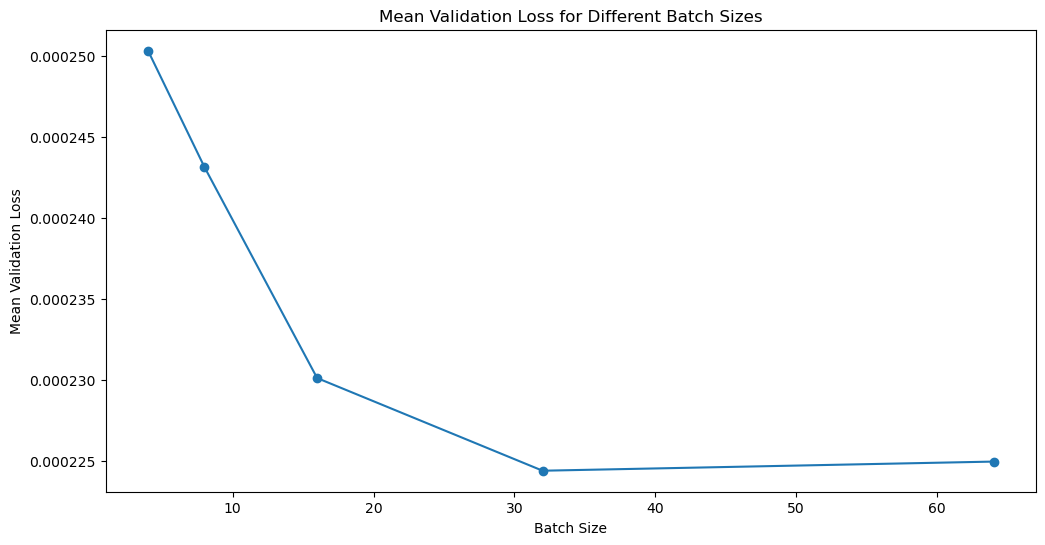


Best Batch Size: 32
Validation Loss at Best Batch Size: 0.0002244195609819144


In [25]:


# List of batch sizes to experiment with
batch_sizes = [64, 32, 16, 8, 4]

# Best number of epochs from the previous step
best_epochs = 5  # Replace with the actual best number of epochs

# Dictionary to store the summary statistics for each batch size
summary_stats = {}

# Iterate over each batch size
for batch_size in batch_sizes:
    print(f"Evaluating batch size: {batch_size}")
    
    # Initialize lists to store losses and run times for the current batch size
    train_losses = []
    val_losses = []
    run_times = []

    # Number of runs for each batch size
    runs = 30

    # Run training loop for the specified number of runs
    for run in range(runs):

        # Start time measurement
        start_time = time.time()
        
        # Fit the model
        history = model.fit(x_train, y_train, epochs=best_epochs, batch_size=batch_size, validation_data=(x_valid, y_valid), verbose=1)
        
        # End time measurement
        end_time = time.time()

        # Store epoch losses
        train_losses.append(history.history['loss'])
        val_losses.append(history.history['val_loss'])

        # Append run time
        run_times.append(end_time - start_time)

        # Print progress
        print(f"Run {run + 1}/{runs} completed in {end_time - start_time} sec")

    # Store the losses and run times for the current batch size
    summary_stats[batch_size] = {
        'Train Loss': train_losses,
        'Validation Loss': val_losses,
        'Run Time': run_times
    }
    # Calculate summary statistics for the current batch size
    train_loss_stats = {
        'Mean': np.mean(train_losses),
        'Std Dev': np.std(train_losses),
        'Min': np.min(train_losses),
        'Max': np.max(train_losses)
    }

    val_loss_stats = {
        'Mean': np.mean(val_losses),
        'Std Dev': np.std(val_losses),
        'Min': np.min(val_losses),
        'Max': np.max(val_losses)
    }

    run_time_stats = {
        'Mean': np.mean(run_times),
        'Std Dev': np.std(run_times),
        'Min': np.min(run_times),
        'Max': np.max(run_times)
    }

    # Store the summary statistics for the current batch size
    summary_stats[batch_size] = {
        'Train Loss': train_loss_stats,
        'Validation Loss': val_loss_stats,
        'Run Time': run_time_stats
    }

    # Print summary statistics for the current batch size
    print(f"\nSummary for batch size {batch_size}:")
    print("Train Loss Summary Statistics:")
    for stat, value in train_loss_stats.items():
        print(f"{stat}: {value}")

    print("Validation Loss Summary Statistics:")
    for stat, value in val_loss_stats.items():
        print(f"{stat}: {value}")

    print("Run Time Summary Statistics:")
    for stat, value in run_time_stats.items():
        print(f"{stat}: {value}")

# Plot the mean validation losses for each batch size
mean_val_losses = [summary_stats[bs]['Validation Loss']['Mean'] for bs in batch_sizes]
plt.figure(figsize=(12, 6))
plt.plot(batch_sizes, mean_val_losses, marker='o')
plt.xlabel('Batch Size')
plt.ylabel('Mean Validation Loss')
plt.title('Mean Validation Loss for Different Batch Sizes')
plt.show()

# Find the best batch size based on the lowest mean validation loss
best_batch_size = batch_sizes[np.argmin(mean_val_losses)]
print(f"\nBest Batch Size: {best_batch_size}")
print(f"Validation Loss at Best Batch Size: {min(mean_val_losses)}")

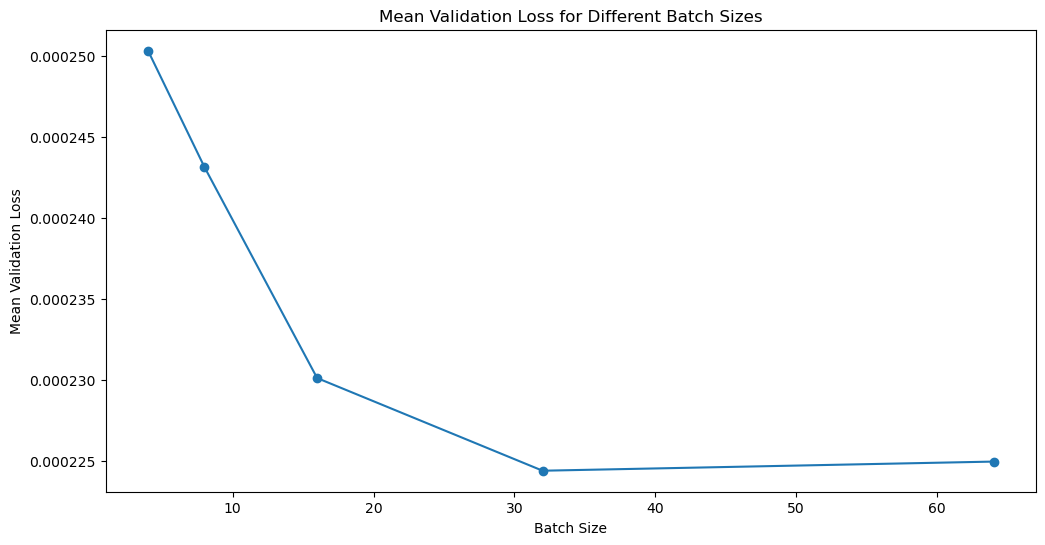

In [27]:
plt.figure(figsize=(12, 6))
plt.plot(batch_sizes, mean_val_losses, marker='o')
plt.xlabel('Batch Size')
plt.ylabel('Mean Validation Loss')
plt.title('Mean Validation Loss for Different Batch Sizes')
plt.savefig('mean_validation_loss.png')  
plt.show()

In [ ]:
neurons = [32, 64, 128, 256, 512]

best_epochs = 5

# Best batch size from the previous step
best_batch_size = 8

# Dictionary to store the summary statistics for each number of neurons
summary_stats_neurons = {}

# Iterate over each number of neurons
for neuron in neurons:
    print(f"Evaluating number of neurons: {neuron}")
    
    # Initialize lists to store losses and run times for the current number of neurons
    train_losses_all = []
    val_losses_all = []
    run_times_all = []

    # Number of runs for each number of neurons
    runs = 30

    # Build the LSTM model with the current number of neurons
    model_neurons = Sequential()
    model_neurons.add(LSTM(units=neuron, return_sequences=True, input_shape=(x_train.shape[1], 1)))
    model_neurons.add(Dropout(0.2))
    model_neurons.add(LSTM(units=neuron, return_sequences=True))
    model_neurons.add(Dropout(0.2))
    model_neurons.add(LSTM(units=neuron, return_sequences=True))
    model_neurons.add(Dropout(0.2))
    model_neurons.add(LSTM(units=neuron))
    model_neurons.add(Dropout(0.2))
    model_neurons.add(Dense(1))

    # Compile the model
    model_neurons.compile(optimizer=Adam(learning_rate=0.01), loss='mean_squared_error')

    # Run training loop for the specified number of runs
    for run in range(runs):
# Initialize lists to store losses and run times for the current run
train_losses = []
val_losses = []
run_times = []

# Run training loop for the specified number of runs
for run in range(runs):

    # Initialize lists to store losses for each epoch in the current run
    epoch_train_losses = []
    epoch_val_losses = []

    # Start time measurement
    start_time = time.time()
    
    # Fit the model
    history = model_neurons.fit(x_train, y_train, epochs=best_epochs, batch_size=best_batch_size, validation_data=(x_valid, y_valid), verbose=1)
    
    # End time measurement
    end_time = time.time()

    # Store epoch losses for the current run
    epoch_train_losses.extend(history.history['loss'])
    epoch_val_losses.extend(history.history['val_loss'])

    # Append run time for the current run
    run_times.append(end_time - start_time)

    # Append epoch losses for the current run
    train_losses.append(epoch_train_losses)
    val_losses.append(epoch_val_losses)

    # Print progress
    print(f"Run {run + 1}/{runs} completed in {end_time - start_time} sec")

# Store the losses and run times for the current number of neurons
summary_stats_neurons[neuron] = {
    'Train Loss': train_losses,
    'Validation Loss': val_losses,
    'Run Time': run_times
}

In [ ]:
# Calculate and print summary statistics for each number of neurons
for neuron, stats in summary_stats_neurons.items():
    train_loss_means = np.mean(stats['Train Loss'], axis=0)
    val_loss_means = np.mean(stats['Validation Loss'], axis=0)
    run_time_mean = np.mean(stats['Run Time'])
    run_time_std = np.std(stats['Run Time'])
    run_time_min = np.min(stats['Run Time'])
    run_time_max = np.max(stats['Run Time'])

    print(f"\nSummary for {neuron} neurons:")
    print(f"Mean Train Loss: {np.mean(train_loss_means)}, Std Dev: {np.std(train_loss_means)}, Min: {np.min(train_loss_means)}, Max: {np.max(train_loss_means)}")
    print(f"Mean Validation Loss: {np.mean(val_loss_means)}, Std Dev: {np.std(val_loss_means)}, Min: {np.min(val_loss_means)}, Max: {np.max(val_loss_means)}")
    print(f"Run Time: Mean = {run_time_mean}, Std Dev = {run_time_std}, Min = {run_time_min}, Max = {run_time_max}")

# Plot the mean validation losses for each number of neurons
mean_val_losses_neurons = [np.mean([np.mean(run) for run in summary_stats_neurons[n]['Validation Loss']]) for n in neurons]
plt.figure(figsize=(12, 6))
plt.plot(neurons, mean_val_losses_neurons, marker='o')
plt.xlabel('Number of Neurons')
plt.ylabel('Mean Validation Loss')
plt.title('Mean Validation Loss for Different Number of Neurons in Hidden Layer')
plt.show()

# Find the optimal number of neurons based on the lowest mean validation loss
optimal_neurons = neurons[np.argmin(mean_val_losses_neurons)]
print(f"\nOptimal Number of Neurons: {optimal_neurons}")
print(f"Validation Loss at Optimal Number of Neurons: {min(mean_val_losses_neurons)}")